In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sqlalchemy import create_engine

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') 

engine = create_engine(
    "postgresql+psycopg2://",
    connect_args={
        "host":     "localhost",
        "port":     5432,
        "dbname":   "financial_stress_db",
        "user":     "postgres",
        "password": "Time@till2030"
    }
)

with engine.connect() as conn:
    print("✅ Connected!")

✅ Connected!


In [2]:
df = pd.read_sql('SELECT * FROM v_analysis', engine)

print(f"Rows: {len(df):,}")       
print(f"Columns: {df.shape[1]}")  
df.head()

Rows: 180,000
Columns: 18


,time_id,year,month,quarter,user_id,age_group,education,marriage,credit_limit,bill_amount,payment_amount,payment_ratio,repayment_status,defaulted_next_month,unemployment_rate,inflation_rate,interest_rate,consumer_confidence
0,2005-04,2005,4,2,1,20s,university,married,20000.0,3913.0,0.0,0.000000,2,1,4.2,2.1,1.75,102.0
1,2005-04,2005,4,2,2,20s,university,single,120000.0,2682.0,0.0,0.000000,-1,1,4.2,2.1,1.75,102.0
2,2005-04,2005,4,2,3,30s,university,single,90000.0,29239.0,1518.0,0.051917,0,0,4.2,2.1,1.75,102.0
3,2005-04,2005,4,2,4,30s,university,married,50000.0,46990.0,2000.0,0.042562,0,0,4.2,2.1,1.75,102.0
4,2005-04,2005,4,2,5,50+,university,married,50000.0,8617.0,2000.0,0.232099,-1,0,4.2,2.1,1.75,102.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   time_id               180000 non-null  object 
 1   year                  180000 non-null  int64  
 2   month                 180000 non-null  int64  
 3   quarter               180000 non-null  int64  
 4   user_id               180000 non-null  int64  
 5   age_group             180000 non-null  object 
 6   education             180000 non-null  object 
 7   marriage              180000 non-null  object 
 8   credit_limit          180000 non-null  float64
 9   bill_amount           180000 non-null  float64
 10  payment_amount        180000 non-null  float64
 11  payment_ratio         180000 non-null  float64
 12  repayment_status      180000 non-null  int64  
 13  defaulted_next_month  180000 non-null  int64  
 14  unemployment_rate     180000 non-null  float64
 15  

In [4]:
df.describe()

,year,month,quarter,user_id,credit_limit,bill_amount,payment_amount,payment_ratio,repayment_status,defaulted_next_month,unemployment_rate,inflation_rate,interest_rate,consumer_confidence
count,180000.0,180000.00000,180000.000000,180000.000000,180000.000000,1.800000e+05,1.800000e+05,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,2005.0,6.50000,2.500000,15000.500000,167484.322667,4.497695e+04,5.275232e+03,1.450334,-0.182439,0.221200,4.033333,2.816667,2.208333,97.833333
std,0.0,1.70783,0.500001,8660.278089,129745.859494,6.683443e+04,1.784690e+04,51.668756,1.165641,0.415056,0.094281,0.474050,0.335928,3.184171
min,2005.0,4.00000,2.000000,1.000000,10000.000000,-3.396030e+05,0.000000e+00,0.000000,-2.000000,0.000000,3.900000,2.100000,1.750000,93.000000
25%,2005.0,5.00000,2.000000,7500.750000,50000.000000,2.400000e+03,3.900000e+02,0.009623,-1.000000,0.000000,4.000000,2.400000,2.000000,95.000000
50%,2005.0,6.50000,2.500000,15000.500000,140000.000000,1.927000e+04,1.900000e+03,0.043235,0.000000,0.000000,4.000000,2.850000,2.125000,98.000000
75%,2005.0,8.00000,3.000000,22500.250000,240000.000000,5.741700e+04,4.592000e+03,0.164438,0.000000,0.000000,4.100000,3.200000,2.500000,101.000000
max,2005.0,9.00000,3.000000,30000.000000,1000000.000000,1.664089e+06,1.684259e+06,11453.666667,8.000000,1.000000,4.200000,3.500000,2.750000,102.000000


# Chart 1: Default Rate vs Inflation Over Time

In [5]:
monthly=df.groupby('time_id').agg(
    default_rate=('defaulted_next_month', 'mean'),
    inflation=('inflation_rate','first'),
    unemployment=('unemployment_rate', 'first')
).reset_index()

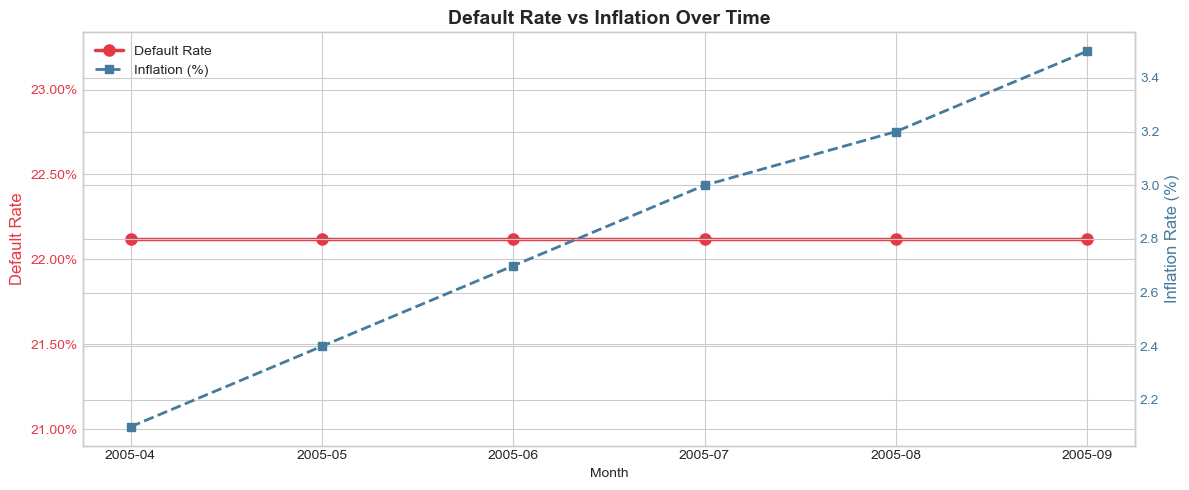

In [6]:
fig, ax1=plt.subplots(figsize=(12,5))

# Left y-axis: default rate
ax1.plot(monthly['time_id'], monthly['default_rate'],
         color='#E63946', linewidth=2.5, marker='o', markersize=8,
         label='Default Rate')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1.set_ylabel('Default Rate', color='#E63946', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#E63946')

# Right y-axis: inflation (twinx() creates a second axis sharing the same x)
ax2 = ax1.twinx()
ax2.plot(monthly['time_id'], monthly['inflation'],
         color='#457B9D', linewidth=2, linestyle='--', marker='s',
         label='Inflation (%)')
ax2.set_ylabel('Inflation Rate (%)', color='#457B9D', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#457B9D')

# Combined legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

ax1.set_title('Default Rate vs Inflation Over Time',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
plt.tight_layout()
plt.savefig('chart_trend_0.png', dpi=150)
plt.show()

# Chart 2: Repayment Stress VS Inflamation Over Time

   time_id  avg_repayment_stress  avg_payment_ratio  inflation
0  2005-04             -0.016700           1.622267        2.1
1  2005-05             -0.133767           1.488137        2.4
2  2005-06             -0.166200           1.611314        2.7
3  2005-07             -0.220667           1.613330        3.0
4  2005-08             -0.266200           1.071785        3.2
5  2005-09             -0.291100           1.295170        3.5


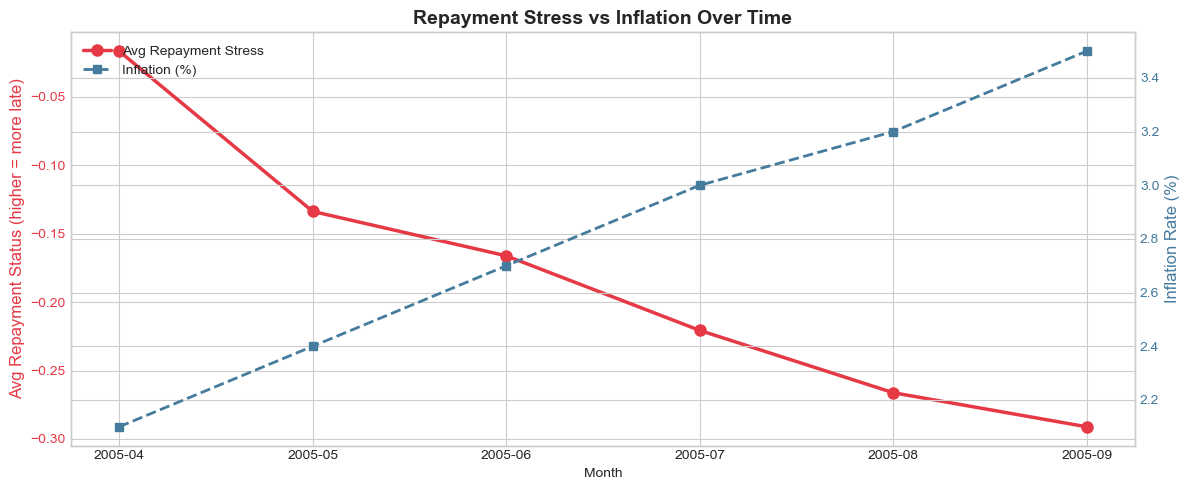

In [7]:
monthly2 = df.groupby('time_id').agg(
    avg_repayment_stress=('repayment_status', 'mean'),
    avg_payment_ratio=('payment_ratio', 'mean'),
    inflation=('inflation_rate', 'first')
).reset_index()

print(monthly2) 

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly2['time_id'], monthly2['avg_repayment_stress'],
         color='#E63946', linewidth=2.5, marker='o', markersize=8,
         label='Avg Repayment Stress')
ax1.set_ylabel('Avg Repayment Status (higher = more late)', 
               color='#E63946', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#E63946')

ax2 = ax1.twinx()
ax2.plot(monthly2['time_id'], monthly2['inflation'],
         color='#457B9D', linewidth=2, linestyle='--', marker='s',
         label='Inflation (%)')
ax2.set_ylabel('Inflation Rate (%)', color='#457B9D', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#457B9D')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

ax1.set_title('Repayment Stress vs Inflation Over Time',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
plt.tight_layout()
plt.savefig('chart_trend_1.png', dpi=150)
plt.show()

In [8]:
# Monthly summary using repayment stress
monthly = df.groupby('time_id').agg(
    pct_late=('repayment_status', lambda x: (x >= 1).mean()),
    avg_bill=('bill_amount', 'mean'),
    avg_payment_ratio=('payment_ratio', 'mean'),
    inflation=('inflation_rate', 'first')
).reset_index()

print(monthly)

   time_id  pct_late      avg_bill  avg_payment_ratio  inflation
0  2005-04  0.227267  51223.330900           1.622267        2.1
1  2005-05  0.147933  49179.075167           1.488137        2.4
2  2005-06  0.140433  47013.154800           1.611314        2.7
3  2005-07  0.117000  43262.948967           1.613330        3.0
4  2005-08  0.098933  40311.400967           1.071785        3.2
5  2005-09  0.102633  38871.760400           1.295170        3.5


# Chart 3: Late Payment  Rate VS Inflation (Rolling Average + Lag)

Correlation (late payments vs inflation 2 months prior): -0.902



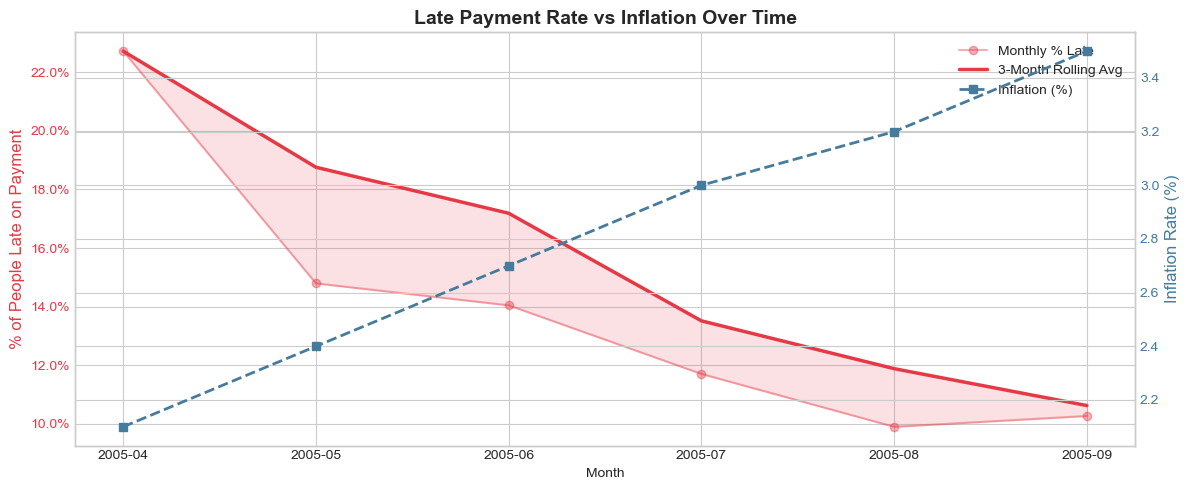

In [9]:
# Rolling Average
# Smooth out the pct_late column over 3 months
monthly['rolling3'] = monthly['pct_late'].rolling(window=3, min_periods=1).mean()

# Lag inflation by 2 months
# Shift inflation down 2 rows to check if past inflation predicts late payments
monthly['inflation_lag2'] = monthly['inflation'].shift(2)

# Check correlation
# Compare pct_late with inflation from 2 months ago
corr = monthly['pct_late'].corr(monthly['inflation_lag2'].ffill())
print(f"Correlation (late payments vs inflation 2 months prior): {corr:.3f}")
print()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis — late payment rate (raw + smoothed)
ax1.plot(monthly['time_id'], monthly['pct_late'],
         alpha=0.4, color='#E63946',
         marker='o', label='Monthly % Late')

ax1.plot(monthly['time_id'], monthly['rolling3'],
         color='#E63946', linewidth=2.5,
         label='3-Month Rolling Avg')

ax1.fill_between(monthly['time_id'],
    monthly['pct_late'], monthly['rolling3'],
    alpha=0.15, color='#E63946')

ax1.set_ylabel('% of People Late on Payment', color='#E63946', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#E63946')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Right axis — inflation
ax2 = ax1.twinx()
ax2.plot(monthly['time_id'], monthly['inflation'],
         color='#457B9D', linewidth=2,
         linestyle='--', marker='s', label='Inflation (%)')
ax2.set_ylabel('Inflation Rate (%)', color='#457B9D', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#457B9D')

# Combine both legends into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')

ax1.set_title('Late Payment Rate vs Inflation Over Time',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')

plt.tight_layout()
plt.savefig('chart_trend_2.png', dpi=150)
plt.show()

# Chart 4: Correlation Heatmap

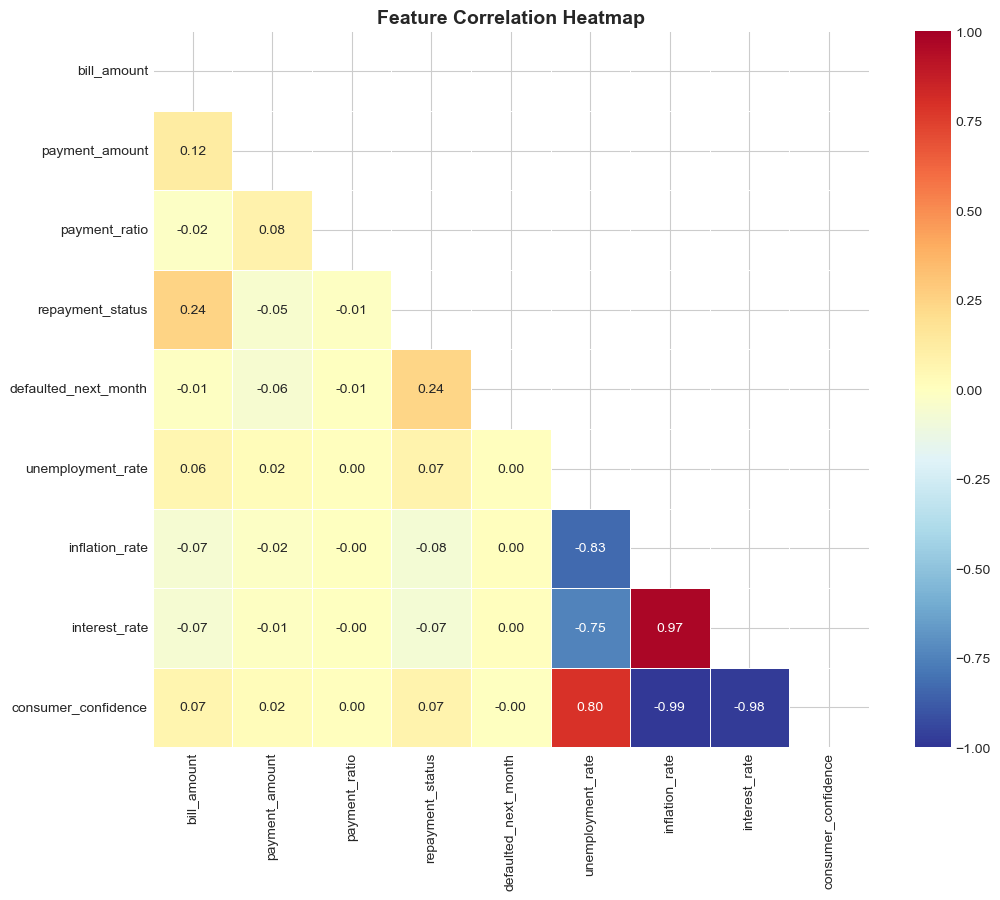

In [10]:
# Selected the numeric columns we want to compare
num_cols = ['bill_amount', 'payment_amount', 'payment_ratio',
            'repayment_status', 'defaulted_next_month',
            'unemployment_rate', 'inflation_rate',
            'interest_rate', 'consumer_confidence']

# Calculated correlation between every pair of columns
# Result is a table of numbers between -1 and +1
corr_matrix = df[num_cols].corr()

# heatmap
fig, ax = plt.subplots(figsize=(11, 9))

# mask hides the upper triangle to avoid showing duplicates
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,       
            fmt='.2f',        
            cmap='RdYlBu_r',  # red = high correlation, blue = negative
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_trend_3.png', dpi=150)
plt.show()

# Chart 5: Cohort Heatmap

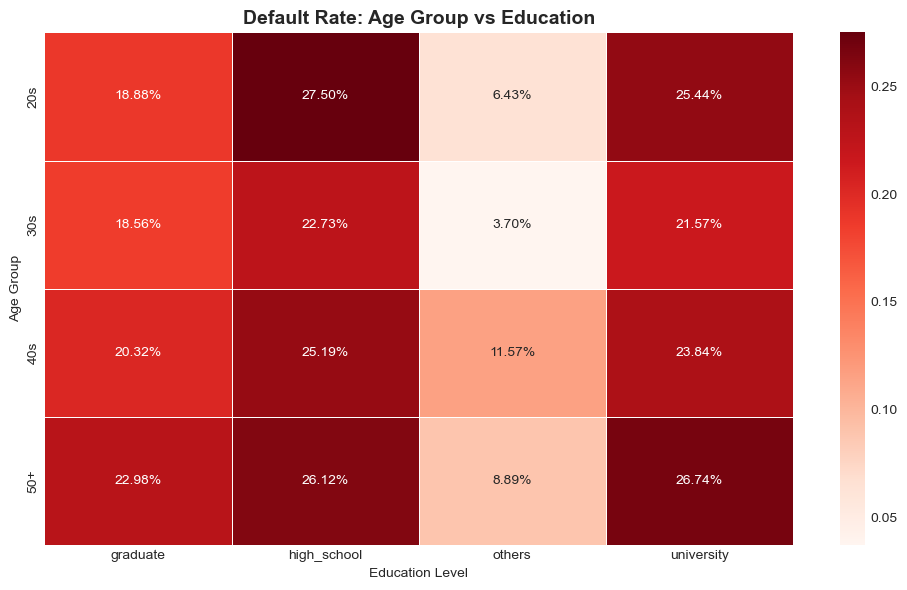

In [11]:
# Group by age group AND education together
# Finding the default rate for each combination
cohort = df.groupby(['age_group', 'education'])['defaulted_next_month'] \
           .mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cohort,
            annot=True,
            fmt='.2%',  
            cmap='Reds',      # white = low default, dark red = high default
            linewidths=0.5,
            ax=ax)

ax.set_title('Default Rate: Age Group vs Education',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Age Group')
plt.tight_layout()
plt.savefig('chart_trend_4.png', dpi=150)
plt.show()

# Chart 6: Default Rate by Age Group (Bar Chart)

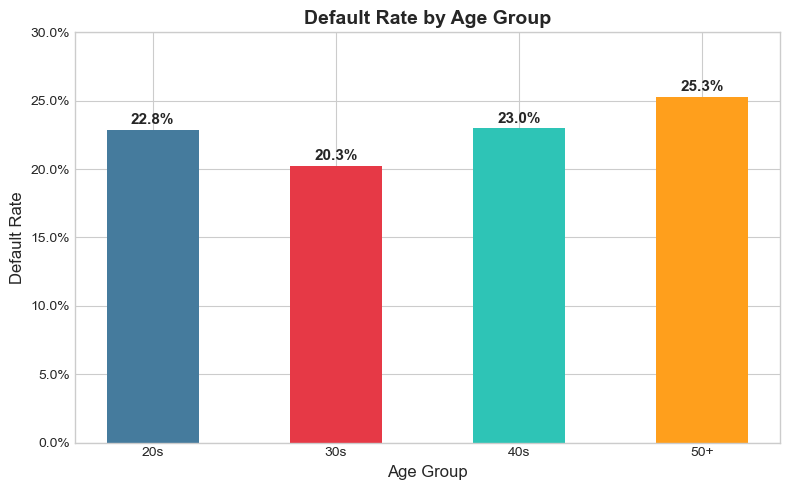

In [12]:
age_default = df.groupby('age_group')['defaulted_next_month'] \
               .mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(age_default['age_group'],
              age_default['defaulted_next_month'],
              color=['#457B9D','#E63946','#2EC4B6','#FF9F1C'],
              width=0.5)

# Added percentage label on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.1%}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Default Rate', fontsize=12)
ax.set_ylim(0, 0.30)

plt.tight_layout()
plt.savefig('chart_trend_5.png', dpi=150)
plt.show()